# 🧠 Full-Pitt Audio-First Cognitive Screening — **Final Pipeline (552 recordings)**
### Raw audio → AD / non-AD, with an interpretable concept scorecard and adaptive early-exit.

```
Pitt .wav ─► diarize (PAR-only, from .cha timestamps) ─► split into utterances
   per utterance:  [wav2vec 2.0 + prosody] token   +   Whisper→BERT token     (aligned sequences)
      └─ gated cross-attention (text⇄audio) ─► discourse encoder (BiGRU+attn)
           └─ concept bottleneck (24 clinical markers) ─► linear head
                └─ AD / non-AD  +  confidence  +  scorecard  +  early-exit
```

**Data:** full DementiaBank **Pitt Cookie-Theft** corpus — **552 recordings, 292 speakers** (309 AD / 243 CN). ~3.3× the ADReSSo subset. Labels and gold speaker segmentation both come from the `.cha` transcripts; the audio is the `.wav` files.

**Evaluation (mathematically rigorous):** **speaker-independent, repeated, stratified GROUP k-fold** — grouped by the 292 speakers so no person is in train and test at once, stratified by label, repeated for stable out-of-fold estimates. This replaces the noisy single-split evaluation.

**Diarization is a single swappable function** (`diarize`): gold `.cha` timestamps for training/paper; swap in Silero-VAD / pyannote for a fully audio-only deployment.

> **Runtime → GPU.** Upload `Pitt.zip` (transcripts) + `Audio.zip` (dementia/ + control/ wavs), or set the paths. Heavy feature extraction over 552 files caches per file and resumes (~30–45 min once); CV training is fast afterwards.

## 0 · Install & imports

In [1]:
import sys, subprocess
def pipq(*p): subprocess.run([sys.executable,"-m","pip","install","-q",*p], check=False)
pipq("faster-whisper","transformers","librosa","soundfile","audioread","praat-parselmouth",
     "spacy","scikit-learn","pylangacq==0.23.0","tqdm")
subprocess.run("apt-get -qq install -y ffmpeg",shell=True,check=False)  # MP3 decode backend (usually preinstalled on Colab)
subprocess.run([sys.executable,"-m","spacy","download","en_core_web_sm","-q"], check=False)
import os, glob, json, random, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import torch, torch.nn as nn, torch.nn.functional as F
DEVICE="cuda" if torch.cuda.is_available() else "cpu"; AMP=(DEVICE=="cuda")
print("torch",torch.__version__,"| device:",DEVICE)
if DEVICE=="cpu": print("⚠️  No GPU — enable it (Runtime → Change runtime type).")

torch 2.11.0+cu128 | device: cuda


## 1 · Configuration

In [2]:
class CFG:
    PITT_ZIP=None; AUDIO_ZIP=None       # None = auto-search /content & Drive; or set explicit paths
    LIMIT=None                          # None = all 552; set 6 for a quick smoke-test
    MIN_SEG_S=0.30
    WHISPER_MODEL="large-v3-turbo"      # "large-v3" (best) / "distil-large-v3" (EN speed)
    ASR_BATCH=16
    W2V_MODEL="microsoft/wavlm-base-plus"; BERT_MODEL="roberta-base"; MAX_UTTS=40  # stronger, task-matched encoders (same 768-d, drop-in)
    D_MODEL=128; HEADS=4; DROPOUT=0.3; LAMBDA_CONCEPT=5.0
    EPOCHS=80; PATIENCE=15; LR=1e-3; WEIGHT_DECAY=1e-4; BATCH=16
    KFOLDS=5; REPEATS=3                 # speaker-independent repeated stratified GROUP k-fold
    THRESHOLD_MODE="youden"; SENS_FLOOR=0.85
    RUN_COMPARISONS=True
    CUTOFFS_S=[10,20,30,45,60,90,999]; KNEE_TOL=0.02
    WORK="/content/work" if os.path.isdir("/content") else "/tmp/work"
CFG.FEAT=os.path.join(CFG.WORK,"pitt_feat2"); CFG.TXTC=os.path.join(CFG.WORK,"pitt_txt2"); CFG.AUDC=os.path.join(CFG.WORK,"pitt_aud2")  # v2: WavLM+RoBERTa -> re-extract once
for d in [CFG.WORK,CFG.FEAT,CFG.TXTC,CFG.AUDC]: os.makedirs(d,exist_ok=True)
def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
set_seed(0); print("config ready · ASR =",CFG.WHISPER_MODEL,"·",CFG.REPEATS,"x",CFG.KFOLDS,"CV")
if DEVICE=="cpu" and CFG.LIMIT is None:
    raise RuntimeError(">>> NO GPU. Full 552-file extraction is impractical on CPU.\n"
                       ">>> FIX: Runtime -> Change runtime type -> GPU (T4), then Run all.\n"
                       ">>> Smoke-test on CPU: set CFG.LIMIT=6.")

config ready · ASR = large-v3-turbo · 3 x 5 CV


## 2 · Load full Pitt — labels + gold diarization (.cha) + matching audio (.wav)

In [3]:
import zipfile, pylangacq
def _grab(name, hint):
    if hint and os.path.exists(hint): return hint
    c=glob.glob(f"/content/drive/**/{name}",recursive=True)+glob.glob(f"/content/**/{name}",recursive=True)+glob.glob(os.path.join(CFG.WORK,name))
    return c[0] if c else None
# mount drive if present
try:
    from google.colab import drive
    if not os.path.isdir("/content/drive"): drive.mount("/content/drive")
except Exception: pass
# upload if not found
pz=_grab("Pitt.zip",CFG.PITT_ZIP); az=_grab("Audio.zip",CFG.AUDIO_ZIP)
if not (pz and az):
    try:
        from google.colab import files
        print("Upload Pitt.zip AND Audio.zip:"); up=files.upload()
        for fn in up: os.replace(fn,os.path.join(CFG.WORK,fn))
        pz=pz or _grab("Pitt.zip",None); az=az or _grab("Audio.zip",None)
    except Exception as e: print("not in Colab:",e)
assert pz and az, "Need both Pitt.zip and Audio.zip."
for z in [pz,az]:
    with zipfile.ZipFile(z) as zf: zf.extractall(CFG.WORK)

def stem(p): return os.path.splitext(os.path.basename(p))[0]
def par_segments(path):
    # GOLD diarization: participant (PAR) turn intervals (seconds) from the CHAT transcript
    r=pylangacq.read_chat(path); out=[]
    for u in r.utterances():
        if u.participant!="PAR": continue
        if u.time_marks:
            s,e=u.time_marks[0]/1000.0, u.time_marks[1]/1000.0
            if e>s: out.append((s,e))
    return out
def diarize(cha_path, wav_path=None):
    # SWAPPABLE: gold .cha timestamps now; replace with Silero-VAD / pyannote for audio-only deployment
    return par_segments(cha_path)

cha = ([(f,1) for f in glob.glob(os.path.join(CFG.WORK,"**","Dementia","cookie","*.cha"),recursive=True)]
      +[(f,0) for f in glob.glob(os.path.join(CFG.WORK,"**","Control","cookie","*.cha"),recursive=True)])
wav_by = {stem(w):w for w in (glob.glob(os.path.join(CFG.WORK,"**","*.mp3"),recursive=True)
                              + glob.glob(os.path.join(CFG.WORK,"**","*.wav"),recursive=True))}  # accept mp3 or wav
CATALOG={}
for fp,label in cha:
    fid=stem(fp); w=wav_by.get(fid)
    if w is None: continue
    utts=diarize(fp,w)
    if utts: CATALOG[fid]={"wav":w,"y":label,"pid":fid.split("-")[0],"utts":utts,"cha":fp}
ITEMS=sorted(CATALOG.items())
if CFG.LIMIT: ITEMS=ITEMS[:CFG.LIMIT]
n_ad=sum(v["y"]==1 for _,v in ITEMS); n_cn=sum(v["y"]==0 for _,v in ITEMS)
n_spk=len(set(v["pid"] for _,v in ITEMS))
print(f"recordings: {len(ITEMS)} (AD={n_ad}, CN={n_cn}) · unique speakers: {n_spk}")
assert len(ITEMS)>0 and len({v['y'] for _,v in ITEMS})==2, "Need both classes with matching audio."
# audio-integrity check: catch empty / OneDrive-placeholder files (should be hundreds of KB, not a few bytes)
import os as _os
_sizes=[_os.path.getsize(v["wav"]) for _,v in ITEMS]
_tiny=sum(1 for s in _sizes if s<2000)
print(f"audio size: min {min(_sizes)} B, median {sorted(_sizes)[len(_sizes)//2]} B, max {max(_sizes)} B")
assert _tiny==0, (f">>> {_tiny}/{len(_sizes)} audio files are empty/tiny (<2 KB) — these are placeholder stubs, "
                  "not real audio.\n>>> Fix on your PC: make OneDrive download the real files (Always keep on this device), "
                  "verify each .wav is hundreds of KB, then re-zip Audio.zip and re-upload.")


Mounted at /content/drive
recordings: 552 (AD=309, CN=243) · unique speakers: 292
audio size: min 127612 B, median 466014 B, max 2141060 B


## 3 · Load encoders (Whisper batched, wav2vec 2.0, BERT, spaCy)

In [4]:
from transformers import Wav2Vec2Model, AutoFeatureExtractor, AutoTokenizer, AutoModel
import librosa, parselmouth
from parselmouth.praat import call
import spacy
NLP=spacy.load("en_core_web_sm", disable=["ner","lemmatizer"])
CT="float16" if DEVICE=="cuda" else "int8"
try:
    from faster_whisper import WhisperModel, BatchedInferencePipeline
    _m=WhisperModel(CFG.WHISPER_MODEL,device=DEVICE,compute_type=CT); ASR=BatchedInferencePipeline(model=_m); BATCHED=True
    print("Whisper (batched):",CFG.WHISPER_MODEL)
except Exception as e:
    from faster_whisper import WhisperModel
    ASR=WhisperModel(CFG.WHISPER_MODEL,device=DEVICE,compute_type=CT); BATCHED=False
    print("Whisper (unbatched):",CFG.WHISPER_MODEL,"|",repr(e)[:70])
W2V_FE=AutoFeatureExtractor.from_pretrained(CFG.W2V_MODEL); W2V=AutoModel.from_pretrained(CFG.W2V_MODEL).to(DEVICE).eval()  # AutoModel -> WavLMModel or Wav2Vec2Model
BTOK=AutoTokenizer.from_pretrained(CFG.BERT_MODEL); BERT=AutoModel.from_pretrained(CFG.BERT_MODEL).to(DEVICE).eval()
TEXT_DIM=BERT.config.hidden_size; W2V_DIM=W2V.config.hidden_size
print(f"encoders ready · BERT {TEXT_DIM} · wav2vec2 {W2V_DIM}")

Whisper (batched): large-v3-turbo


preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.23k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  378MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


encoders ready · BERT 768 · wav2vec2 768


## 4 · Feature functions (audio → aligned tokens + self-derived concepts)

In [5]:
FILLERS={"um","uh","er","erm","hmm","mm","uhh","umm"}
import soundfile as sf, subprocess, shutil
_FFMPEG=shutil.which("ffmpeg")
def _load_ffmpeg(path, target_sr=16000):
    # decode ANY container (these Pitt files are MP3 with a .wav extension) via system ffmpeg -> float32 mono
    cmd=[_FFMPEG,"-nostdin","-v","error","-i",path,"-f","f32le","-ac","1","-ar",str(target_sr),"-"]
    p=subprocess.run(cmd,stdout=subprocess.PIPE,stderr=subprocess.PIPE)
    if p.returncode!=0 or not p.stdout:
        raise RuntimeError("ffmpeg decode failed: "+p.stderr.decode()[:160])
    return np.frombuffer(p.stdout,dtype=np.float32).copy(), target_sr
def load_audio(path, target_sr=16000):
    # 1) real WAV via soundfile; 2) MP3/other via ffmpeg; 3) librosa fallback
    try:
        y,sr=sf.read(path, dtype='float32', always_2d=False)
        if getattr(y,'ndim',1)>1: y=y.mean(axis=1)
        y=np.asarray(y,dtype='float32')
        if sr!=target_sr:
            import librosa as _lb; y=_lb.resample(y,orig_sr=sr,target_sr=target_sr).astype('float32')
        return y,target_sr
    except Exception:
        pass
    if _FFMPEG:
        try: return _load_ffmpeg(path,target_sr)
        except Exception: pass
    import librosa as _lb; y,sr=_lb.load(path,sr=target_sr,mono=True); return np.asarray(y,'float32'),sr
def acoustic_markers(y,sr):
    f={}
    try:
        snd=parselmouth.Sound(y.astype(np.float64),sampling_frequency=sr)
        pitch=snd.to_pitch(); f0=pitch.selected_array['frequency']; f0=f0[f0>0]
        f["f0_mean"]=float(np.mean(f0)) if len(f0) else np.nan
        f["f0_std"]=float(np.std(f0)) if len(f0) else np.nan
        f["f0_range"]=float(np.ptp(f0)) if len(f0) else np.nan
        pp=call(snd,"To PointProcess (periodic, cc)",75,500)
        f["jitter_local"]=call(pp,"Get jitter (local)",0,0,1e-4,0.02,1.3)
        f["shimmer_local"]=call([snd,pp],"Get shimmer (local)",0,0,1e-4,0.02,1.3,1.6)
        h=snd.to_harmonicity_cc(); v=h.values[h.values!=-200]; f["hnr"]=float(np.mean(v)) if v.size else np.nan
    except Exception:
        for k in ["f0_mean","f0_std","f0_range","jitter_local","shimmer_local","hnr"]: f[k]=np.nan
    f["spec_centroid"]=float(np.mean(librosa.feature.spectral_centroid(y=y,sr=sr)))
    f["spec_bandwidth"]=float(np.mean(librosa.feature.spectral_bandwidth(y=y,sr=sr)))
    f["zcr"]=float(np.mean(librosa.feature.zero_crossing_rate(y)))
    f["rms_energy"]=float(np.mean(librosa.feature.rms(y=y)))
    return f
def w2v_token(seg,sr):
    if len(seg)<int(0.1*sr): seg=np.pad(seg,(0,int(0.1*sr)-len(seg)))
    with torch.no_grad(), torch.autocast(device_type="cuda",dtype=torch.float16,enabled=AMP):
        iv=W2V_FE(seg,sampling_rate=sr,return_tensors="pt").input_values.to(DEVICE)
        h=W2V(iv).last_hidden_state.mean(1).squeeze(0)
    return h.float().cpu().numpy().astype("float32")
def prosody_token(seg,sr):
    f=np.zeros(8,"float32")
    try:
        if len(seg)<int(0.12*sr): return f
        snd=parselmouth.Sound(seg.astype(np.float64),sampling_frequency=sr)
        pitch=snd.to_pitch(); f0=pitch.selected_array["frequency"]; f0=f0[f0>0]
        if len(f0): f[0]=np.mean(f0)/100.0; f[1]=np.std(f0)/50.0; f[2]=np.ptp(f0)/150.0
        pp=call(snd,"To PointProcess (periodic, cc)",75,500)
        f[3]=call(pp,"Get jitter (local)",0,0,1e-4,0.02,1.3)*100.0
        f[4]=call([snd,pp],"Get shimmer (local)",0,0,1e-4,0.02,1.3,1.6)*10.0
        h=snd.to_harmonicity_cc(); v=h.values[h.values!=-200]; f[5]=(float(np.mean(v))/20.0) if v.size else 0.0
        inten=snd.to_intensity(); iv=inten.values[inten.values>0]
        if iv.size: f[6]=float(np.mean(iv))/60.0; f[7]=float(np.std(iv))/20.0
    except Exception: pass
    return np.nan_to_num(f,nan=0.0,posinf=0.0,neginf=0.0).astype("float32")
def bert_tokens(texts):
    texts=[t if t.strip() else "." for t in texts]; out=[]
    with torch.no_grad(), torch.autocast(device_type="cuda",dtype=torch.float16,enabled=AMP):
        for j in range(0,len(texts),64):
            enc=BTOK(texts[j:j+64],padding=True,truncation=True,max_length=48,return_tensors="pt").to(DEVICE)
            o=BERT(**enc).last_hidden_state; m=enc["attention_mask"].unsqueeze(-1)
            out.append(((o*m).sum(1)/m.sum(1).clamp(min=1)).float().cpu().numpy())
    return np.vstack(out).astype("float32")
def linguistic_markers(words,n_sent,dur,gaps,filled_count=None):
    n=len(words)
    if n==0: return None
    pos=[t.pos_ for t in NLP(" ".join(words))]
    pron=sum(1 for p in pos if p=="PRON"); noun=pos.count("NOUN"); verb=pos.count("VERB")
    content=sum(1 for p in pos if p in {"NOUN","VERB","ADJ","ADV"})
    Wn=25; uniq=len(set(words))
    mattr=float(np.mean([len(set(words[i:i+Wn]))/Wn for i in range(0,max(1,n-Wn+1))])) if n>=Wn else uniq/n
    filled=filled_count if filled_count is not None else sum(1 for w in words if w.lower() in FILLERS)
    gaps=np.array(gaps,float)
    return {"ttr":uniq/n,"mattr":mattr,"mlu_words":n/max(1,n_sent),
            "pronoun_ratio":pron/n,"noun_ratio":noun/n,"verb_ratio":verb/n,
            "pronoun_noun_ratio":pron/max(1,noun),"noun_verb_ratio":noun/max(1,verb),
            "lexical_density":content/n,"filled_pause_rate":filled/n,
            "speech_rate_wpm":(n/(dur/60.0)) if dur>0 else np.nan,
            "mean_pause_ms":float(np.mean(gaps)*1000) if len(gaps) else np.nan,
            "long_pause_ratio":float((gaps>2.0).mean()) if len(gaps) else np.nan}
print("feature functions ready")

feature functions ready


### Stage: extract aligned tokens over all 552 recordings (cached, resumable)

In [6]:
_CK=["ttr","mattr","mlu_words","pronoun_ratio","noun_ratio","verb_ratio","pronoun_noun_ratio",
     "noun_verb_ratio","lexical_density","filled_pause_rate","speech_rate_wpm","mean_pause_ms","long_pause_ratio"]
def build_patient(y,sr,utts,dur_full):
    if not utts: utts=[(0.0,dur_full)]
    sil=np.zeros(int(0.1*sr),"float32"); parts=[]; spans=[]; seg_audio=[]; real=[]; t=0.0; rt=0.0
    for (s,e) in utts:
        if (e-s)<CFG.MIN_SEG_S: continue
        seg=y[int(s*sr):int(e*sr)]
        if len(seg)<int(0.05*sr): continue
        parts+=[seg,sil]; spans.append((t,t+len(seg)/sr)); seg_audio.append(seg); real.append(rt)
        t+=len(seg)/sr+0.1; rt+=len(seg)/sr
    yp=np.concatenate(parts) if parts else y
    if not seg_audio: seg_audio=[y]; spans=[(0.0,len(y)/sr)]; real=[0.0]; rt=len(y)/sr
    return yp,spans,seg_audio,real,rt
def transcribe_words(yp):
    if BATCHED: segs,_=ASR.transcribe(yp,batch_size=CFG.ASR_BATCH,word_timestamps=True)
    else: segs,_=ASR.transcribe(yp,word_timestamps=True)
    W=[]
    for s in segs:
        if s.words:
            for w in s.words: W.append((w.start,w.end,w.word.strip()))
    return W
from tqdm.auto import tqdm
made=done=0
for fid,v in tqdm(ITEMS,desc="extract"):
    fj=os.path.join(CFG.FEAT,f"{fid}.json"); ft=os.path.join(CFG.TXTC,f"{fid}.npy"); fa=os.path.join(CFG.AUDC,f"{fid}.npy")
    if os.path.exists(fj) and os.path.exists(ft) and os.path.exists(fa): done+=1; continue
    try:
        y,sr=load_audio(v["wav"],16000); dur_full=len(y)/sr
        yp,spans,seg_audio,real,pdur=build_patient(y,sr,v["utts"],dur_full)
        words=transcribe_words(yp)
        seg_text=[[] for _ in spans]
        for ws,we,w in words:
            c=0.5*(ws+we)
            for i,(a,b) in enumerate(spans):
                if a<=c<=b: seg_text[i].append(w); break
        utt_texts=[" ".join(t) for t in seg_text][:CFG.MAX_UTTS] or ["."]
        seg_audio=seg_audio[:CFG.MAX_UTTS]; real=real[:CFG.MAX_UTTS]
        Ltok=bert_tokens(utt_texts)
        Atok=np.vstack([np.concatenate([w2v_token(s,sr), prosody_token(s,sr)]) for s in seg_audio]).astype("float32")
        m=min(len(Ltok),len(Atok)); Ltok,Atok=Ltok[:m],Atok[:m]
        allw=[w for t in seg_text for w in t]
        gaps=[max(0.0,words[i][0]-words[i-1][1]) for i in range(1,len(words))]
        # ACOUSTIC filled-pause: voiced gap between words = a filled pause (ASR-independent)
        srms=float(np.sqrt(np.mean(yp**2)+1e-9)); nf=0
        for gi in range(1,len(words)):
            gs,ge=words[gi-1][1],words[gi][0]
            if (ge-gs)<0.15: continue
            gseg=yp[int(gs*sr):int(ge*sr)]
            if len(gseg)<int(0.05*sr): continue
            if np.sqrt(np.mean(gseg**2)+1e-9)>0.35*srms: nf+=1
        lmk=linguistic_markers(allw,max(1,len([t for t in utt_texts if t.strip()])),pdur,gaps,filled_count=nf) or {k:0.0 for k in _CK}
        amk=acoustic_markers(yp,sr)
        rec={**lmk,**amk,"y":int(v["y"]),"pid":v["pid"],"file":fid,
             "seg_meta":[[round(real[i],2)," ".join(seg_text[i])] for i in range(m)]}
        json.dump(rec,open(fj,"w")); np.save(ft,Ltok); np.save(fa,Atok); made+=1
    except Exception as e:
        print("skip",fid,"→",repr(e)[:120])
print(f"features: made {made}, cached {done}, total {len(glob.glob(os.path.join(CFG.FEAT,'*.json')))}")

extract:   0%|          | 0/552 [00:00<?, ?it/s]

features: made 552, cached 0, total 552


## 5 · Collect features

In [7]:
LING=["ttr","mattr","mlu_words","pronoun_ratio","noun_ratio","verb_ratio",
      "pronoun_noun_ratio","noun_verb_ratio","lexical_density","filled_pause_rate",
      "speech_rate_wpm","mean_pause_ms","long_pause_ratio"]
VOICE=["f0_mean","f0_std","f0_range","jitter_local","shimmer_local","hnr",
       "spec_centroid","spec_bandwidth","zcr","rms_energy"]
CONCEPTS=LING+VOICE
rows=[]; TXT={}; AUD={}; SEG={}
for fj in glob.glob(os.path.join(CFG.FEAT,"*.json")):
    r=json.load(open(fj)); fid=r["file"]
    ft=os.path.join(CFG.TXTC,f"{fid}.npy"); fa=os.path.join(CFG.AUDC,f"{fid}.npy")
    if not (os.path.exists(ft) and os.path.exists(fa)): continue
    TXT[fid]=np.load(ft).astype("float32"); AUD[fid]=np.load(fa).astype("float32"); SEG[fid]=r["seg_meta"]; rows.append(r)
df=pd.DataFrame(rows)
assert len(rows)>0, ("No features extracted. Most likely an audio-decode issue (NoBackendError). "
                     "Re-run cells 0 and 3-6 after the soundfile/resampy install, and confirm the .wav files unzipped under work/.")
for c in CONCEPTS: df[c]=pd.to_numeric(df[c],errors="coerce"); df[c]=df[c].fillna(df[c].median())
df=df.reset_index(drop=True)
Y=df["y"].values.astype("float32"); GROUPS=df["pid"].astype(str).values; FILES=df["file"].astype(str).values
C_all=df[CONCEPTS].values.astype("float32")
TEXT_DIM=next(iter(TXT.values())).shape[1]; AUD_DIM=next(iter(AUD.values())).shape[1]
print(f"collected {len(df)} recordings | {df['pid'].nunique()} speakers | concepts {len(CONCEPTS)} | text {TEXT_DIM} | audio {AUD_DIM}")
print("labels:", {int(k):int(v) for k,v in df['y'].value_counts().items()})

collected 552 recordings | 292 speakers | concepts 23 | text 768 | audio 776
labels: {1: 309, 0: 243}


## 6 · Model — gated cross-attention → discourse encoder → concept bottleneck

In [8]:
class CrossAttnFusion(nn.Module):
    def __init__(self,d_text,d_aud,d=128,heads=4,dropout=0.3,maxlen=40):
        super().__init__()
        self.ln_l_in=nn.LayerNorm(d_text); self.ln_a_in=nn.LayerNorm(d_aud)
        self.pl=nn.Linear(d_text,d); self.pa=nn.Linear(d_aud,d); self.pos=nn.Embedding(maxlen,d)
        self.l2a=nn.MultiheadAttention(d,heads,dropout=dropout,batch_first=True)
        self.a2l=nn.MultiheadAttention(d,heads,dropout=dropout,batch_first=True)
        self.ln_l=nn.LayerNorm(d); self.ln_a=nn.LayerNorm(d); self.gate=nn.Linear(2*d,d); self.drop=nn.Dropout(dropout)
    def forward(self,L,A,mask):
        T=L.size(1); pos=self.pos(torch.arange(T,device=L.device))[None]
        L=self.pl(self.ln_l_in(L))+pos; A=self.pa(self.ln_a_in(A))+pos; kpm=~mask
        Lc,_=self.l2a(L,A,A,key_padding_mask=kpm); Ac,_=self.a2l(A,L,L,key_padding_mask=kpm)
        L=self.ln_l(L+Lc); A=self.ln_a(A+Ac); g=torch.sigmoid(self.gate(torch.cat([L,A],-1)))
        return self.drop(torch.relu(g*L+(1-g)*A))
class DiscourseEncoder(nn.Module):
    def __init__(self,d,hid=64,out=128,dropout=0.3):
        super().__init__(); self.gru=nn.GRU(d,hid,batch_first=True,bidirectional=True)
        self.attn=nn.Linear(2*hid,1); self.proj=nn.Sequential(nn.Linear(2*hid,out),nn.ReLU(),nn.Dropout(dropout))
    def forward(self,x,lens):
        p=nn.utils.rnn.pack_padded_sequence(x,lens.cpu().clamp(min=1),batch_first=True,enforce_sorted=False)
        o,_=self.gru(p); o,_=nn.utils.rnn.pad_packed_sequence(o,batch_first=True,total_length=x.size(1))
        m=torch.arange(o.size(1),device=x.device)[None,:]<lens[:,None].clamp(min=1)
        s=self.attn(o).squeeze(-1).masked_fill(~m,float("-inf")); w=torch.softmax(s,1).unsqueeze(-1)
        return self.proj((o*w).sum(1))
class Net(nn.Module):
    def __init__(self,text_dim,aud_dim,n_concepts,d=128,heads=4,dropout=0.3,bottleneck=True,maxlen=40):
        super().__init__(); self.bottleneck=bottleneck
        self.fusion=CrossAttnFusion(text_dim,aud_dim,d,heads,dropout,maxlen); self.disc=DiscourseEncoder(d,64,128,dropout)
        if bottleneck: self.to_concepts=nn.Linear(128,n_concepts); self.head=nn.Linear(n_concepts,1)
        else: self.head=nn.Sequential(nn.Linear(128,64),nn.ReLU(),nn.Dropout(dropout),nn.Linear(64,1))
    def forward(self,L,A,lens):
        mask=torch.arange(L.size(1),device=L.device)[None,:]<lens[:,None].clamp(min=1)
        H=self.fusion(L,A,mask); D=self.disc(H,lens)
        if self.bottleneck: c=self.to_concepts(D); return self.head(c).squeeze(-1), c
        return self.head(D).squeeze(-1), None
print("model defined · cross-attention + discourse + bottleneck")

model defined · cross-attention + discourse + bottleneck


## 7 · Speaker-independent CV utilities (train + validation threshold tuning)

In [9]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
MAXU=CFG.MAX_UTTS
def pad_pair(fid):
    L=TXT[fid]; A=AUD[fid]; n=min(len(L),len(A),MAXU)
    tl=np.zeros((MAXU,L.shape[1]),"float32"); tl[:n]=L[:n]
    ta=np.zeros((MAXU,A.shape[1]),"float32"); ta[:n]=A[:n]
    return tl,ta,max(1,n)
class DS(Dataset):
    def __init__(self,idx,C): self.idx=idx; self.C=C
    def __len__(self): return len(self.idx)
    def __getitem__(self,k):
        i=self.idx[k]; L,A,n=pad_pair(FILES[i])
        return torch.from_numpy(L),torch.from_numpy(A),n,torch.tensor(Y[i]),torch.from_numpy(self.C[i])
def collate(b):
    L,A,n,y,c=zip(*b); return torch.stack(L),torch.stack(A),torch.tensor(n),torch.stack(y),torch.stack(c)
def run_epoch(net,dl,opt=None,lam=1.0):
    train=opt is not None; net.train() if train else net.eval(); P=[];T=[]
    for L,A,n,y,c in dl:
        L,A,n,y,c=[x.to(DEVICE) for x in (L,A,n,y,c)]
        with torch.set_grad_enabled(train):
            logit,cp=net(L,A,n); loss=F.binary_cross_entropy_with_logits(logit,y)
            if net.bottleneck and cp is not None: loss=loss+lam*F.mse_loss(cp,c)
            if train: opt.zero_grad(); loss.backward(); opt.step()
        P.append(torch.sigmoid(logit).detach().cpu().numpy()); T.append(y.cpu().numpy())
    return np.concatenate(P),np.concatenate(T)
def train_once(tr,va,te,C,bottleneck=True,seed=0):
    set_seed(seed)
    net=Net(TEXT_DIM,AUD_DIM,len(CONCEPTS),CFG.D_MODEL,CFG.HEADS,CFG.DROPOUT,bottleneck,MAXU).to(DEVICE)
    opt=torch.optim.Adam(net.parameters(),lr=CFG.LR,weight_decay=CFG.WEIGHT_DECAY)
    dtr=DataLoader(DS(tr,C),batch_size=CFG.BATCH,shuffle=True,collate_fn=collate)
    dva=DataLoader(DS(va,C),batch_size=CFG.BATCH,shuffle=False,collate_fn=collate)
    dte=DataLoader(DS(te,C),batch_size=CFG.BATCH,shuffle=False,collate_fn=collate)
    best=-1;bs=None;wait=0
    for ep in range(CFG.EPOCHS):
        run_epoch(net,dtr,opt,CFG.LAMBDA_CONCEPT)
        Pv,Tv=run_epoch(net,dva); auc=roc_auc_score(Tv,Pv) if len(set(Tv))>1 else 0.5
        if auc>best: best=auc; bs={k:v.cpu().clone() for k,v in net.state_dict().items()}; wait=0
        else:
            wait+=1
            if wait>=CFG.PATIENCE: break
    net.load_state_dict(bs)
    Pv,Tv=run_epoch(net,dva); Pt,Tt=run_epoch(net,dte)
    return net,Pt,Tt,Pv,Tv,te
def pick_threshold(Pv,Tv):
    if len(set(Tv))<2: return 0.5
    best_t,best=0.5,-1.0
    for t in np.unique(np.concatenate([[0.0],np.sort(Pv),[1.0]])):
        pred=(Pv>=t).astype(int); tn,fp,fn,tp=confusion_matrix(Tv,pred,labels=[0,1]).ravel()
        sens=tp/(tp+fn) if (tp+fn) else 0.0; spec=tn/(tn+fp) if (tn+fp) else 0.0
        score=(spec if sens>=CFG.SENS_FLOOR else sens-1.0) if CFG.THRESHOLD_MODE=="sensitivity" else (sens+spec-1.0)
        if score>best: best=score; best_t=float(t)
    return best_t
def inner_val(tr_idx, seed):
    inner=StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=seed)
    tri,vai=next(iter(inner.split(tr_idx,Y[tr_idx],groups=GROUPS[tr_idx])))
    return tr_idx[tri], tr_idx[vai]
print("CV utilities ready · speaker-independent, validation-tuned thresholds")

CV utilities ready · speaker-independent, validation-tuned thresholds


## 8 · Repeated stratified GROUP k-fold → out-of-fold predictions

In [10]:
def cv_oof(bottleneck=True):
    # returns list over repeats of (oof_prob[N], y[N], per-recording threshold[N])
    out=[]
    for rep in range(CFG.REPEATS):
        sgkf=StratifiedGroupKFold(n_splits=CFG.KFOLDS,shuffle=True,random_state=rep)
        oof=np.full(len(df),np.nan); thr=np.full(len(df),0.5)
        for tr_idx,te_idx in sgkf.split(df,Y,groups=GROUPS):
            tr2,va=inner_val(tr_idx,rep)
            sc=StandardScaler().fit(C_all[tr2]); C=sc.transform(C_all).astype("float32")
            _,Pt,Tt,Pv,Tv,_=train_once(tr2,va,te_idx,C,bottleneck,rep)
            oof[te_idx]=Pt; thr[te_idx]=pick_threshold(Pv,Tv)
        a=roc_auc_score(Y,oof)
        print(f"    repeat {rep}: OOF AUC {a:.3f}")
        out.append((oof.copy(),Y.copy(),thr.copy()))
    return out

# leakage assertion (speaker-independent)
_sg=StratifiedGroupKFold(n_splits=CFG.KFOLDS,shuffle=True,random_state=0)
for tr,te in _sg.split(df,Y,groups=GROUPS):
    assert len(set(GROUPS[tr])&set(GROUPS[te]))==0, "speaker leak!"
print("✓ speaker-independent folds verified (no speaker in train & test)\n")

print("▶ Concept-bottleneck (OURS):"); OOF_CB=cv_oof(True)
def summ(oofs):
    A=[roc_auc_score(y,p) for p,y,_ in oofs]
    F=[f1_score(y,(p>=t).astype(int)) for p,y,t in oofs]
    return (np.mean(A),np.std(A)),np.mean(F)
cb=summ(OOF_CB)

lines=[]; OOF_BB=None
if CFG.RUN_COMPARISONS:
    from sklearn.pipeline import make_pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import cross_val_predict
    def sk_oof(cols,mk):
        A=[];F=[]
        X=df[cols].values
        for rep in range(CFG.REPEATS):
            sg=StratifiedGroupKFold(n_splits=CFG.KFOLDS,shuffle=True,random_state=rep)
            p=cross_val_predict(mk(),X,Y,groups=GROUPS,cv=sg,method="predict_proba")[:,1]
            A.append(roc_auc_score(Y,p)); F.append(f1_score(Y,(p>=0.5).astype(int)))
        return np.mean(A),np.mean(F)
    b1=sk_oof(LING, lambda: make_pipeline(SimpleImputer(),StandardScaler(),LogisticRegression(max_iter=1000)))
    b2=sk_oof(CONCEPTS, lambda: make_pipeline(SimpleImputer(),RandomForestClassifier(n_estimators=300,random_state=0)))
    print("▶ Black-box (cross-attn, MLP head):"); OOF_BB=cv_oof(False); bb=summ(OOF_BB)
    lines=[("Linguistic markers + LogReg",b1[0],b1[1]),("All markers + RandomForest",b2[0],b2[1]),
           ("Black-box (cross-attn)",bb[0][0],bb[1])]

print("\n"+"="*58); print(f"{'Model':<38}{'OOF AUC':>10}{'F1':>8}"); print("-"*58)
for n,a,f in lines: print(f"{n:<38}{a:>10.3f}{f:>8.3f}")
print(f"{'Concept-bottleneck (OURS)':<38}{cb[0][0]:>7.3f}±{cb[0][1]:.2f}{cb[1]:>8.3f}")
print("-"*58)
if CFG.RUN_COMPARISONS: print(f"Interpretability cost (blackbox − bottleneck): {bb[0][0]-cb[0][0]:+.3f} AUC")
print("="*58)
print("(AUC threshold-free; deep-model F1 at validation-tuned threshold, baselines at 0.5)")

✓ speaker-independent folds verified (no speaker in train & test)

▶ Concept-bottleneck (OURS):
    repeat 0: OOF AUC 0.705
    repeat 1: OOF AUC 0.738
    repeat 2: OOF AUC 0.724
▶ Black-box (cross-attn, MLP head):
    repeat 0: OOF AUC 0.683
    repeat 1: OOF AUC 0.735
    repeat 2: OOF AUC 0.739

Model                                    OOF AUC      F1
----------------------------------------------------------
Linguistic markers + LogReg                0.665   0.666
All markers + RandomForest                 0.716   0.716
Black-box (cross-attn)                     0.719   0.717
Concept-bottleneck (OURS)               0.722±0.01   0.695
----------------------------------------------------------
Interpretability cost (blackbox − bottleneck): -0.003 AUC
(AUC threshold-free; deep-model F1 at validation-tuned threshold, baselines at 0.5)


## 9 · Research-paper metrics (out-of-fold, mean ± std over repeats)

CONCEPT-BOTTLENECK — OOF metrics (mean ± std, 3 repeats)
  AUC            0.722 ± 0.014
  AUPRC          0.738 ± 0.009
  Accuracy       0.673 ± 0.003
  Balanced acc   0.674 ± 0.008
  Sensitivity    0.669 ± 0.048
  Specificity    0.679 ± 0.062
  Precision      0.729 ± 0.025
  F1             0.695 ± 0.015
  MCC            0.347 ± 0.014


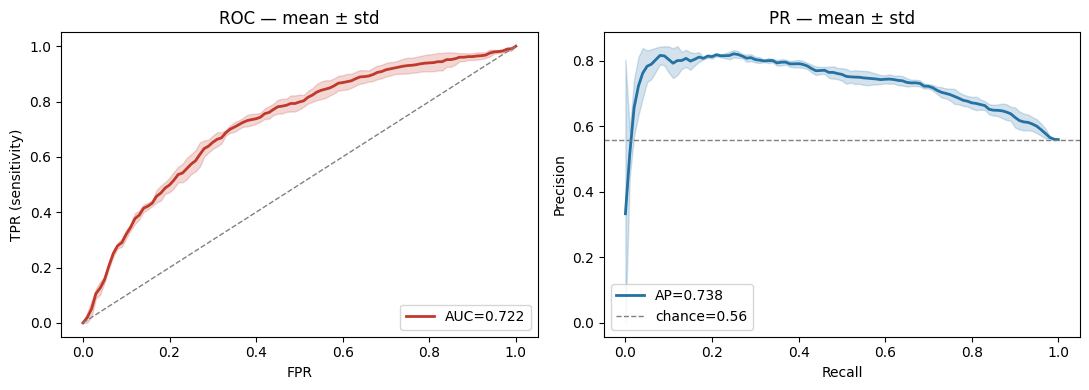

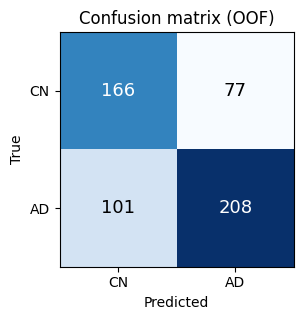

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import (average_precision_score, precision_score, accuracy_score,
    balanced_accuracy_score, matthews_corrcoef, roc_curve, precision_recall_curve)
def metrics_over_repeats(oofs):
    keys=["AUC","AUPRC","Accuracy","Balanced acc","Sensitivity","Specificity","Precision","F1","MCC"]
    M={k:[] for k in keys}
    for P,T,thr in oofs:
        pred=(P>=thr).astype(int); tn,fp,fn,tp=confusion_matrix(T,pred,labels=[0,1]).ravel()
        M["AUC"].append(roc_auc_score(T,P)); M["AUPRC"].append(average_precision_score(T,P))
        M["Accuracy"].append(accuracy_score(T,pred)); M["Balanced acc"].append(balanced_accuracy_score(T,pred))
        M["Sensitivity"].append(tp/(tp+fn) if (tp+fn) else np.nan); M["Specificity"].append(tn/(tn+fp) if (tn+fp) else np.nan)
        M["Precision"].append(precision_score(T,pred,zero_division=0)); M["F1"].append(f1_score(T,pred,zero_division=0)); M["MCC"].append(matthews_corrcoef(T,pred))
    return keys,M
keys,M=metrics_over_repeats(OOF_CB)
print("="*52); print(f"CONCEPT-BOTTLENECK — OOF metrics (mean ± std, {CFG.REPEATS} repeats)"); print("="*52)
for k in keys: print(f"  {k:<14} {np.nanmean(M[k]):.3f} ± {np.nanstd(M[k]):.3f}")

# ROC + PR (mean over repeats) and pooled confusion matrix from repeat 0
def mean_curve(oofs,kind):
    grid=np.linspace(0,1,101); ys=[]
    for P,T,_ in oofs:
        if kind=="roc": x,y,_=roc_curve(T,P); yi=np.interp(grid,x,y); yi[0]=0.0
        else: pr,rc,_=precision_recall_curve(T,P); o=np.argsort(rc); yi=np.interp(grid,rc[o],pr[o])
        ys.append(yi)
    ys=np.array(ys); return grid,ys.mean(0),ys.std(0)
fig,ax=plt.subplots(1,2,figsize=(11,4))
g,m,s=mean_curve(OOF_CB,"roc"); auc=np.mean([roc_auc_score(T,P) for P,T,_ in OOF_CB])
ax[0].plot(g,m,color="#c0392b",lw=2,label=f"AUC={auc:.3f}"); ax[0].fill_between(g,np.clip(m-s,0,1),np.clip(m+s,0,1),color="#c0392b",alpha=.2)
ax[0].plot([0,1],[0,1],"--",c="gray",lw=1); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR (sensitivity)"); ax[0].set_title("ROC — mean ± std"); ax[0].legend(loc="lower right")
g,m,s=mean_curve(OOF_CB,"pr"); ap=np.mean([average_precision_score(T,P) for P,T,_ in OOF_CB]); base=Y.mean()
ax[1].plot(g,m,color="#2471a3",lw=2,label=f"AP={ap:.3f}"); ax[1].fill_between(g,np.clip(m-s,0,1),np.clip(m+s,0,1),color="#2471a3",alpha=.2)
ax[1].axhline(base,ls="--",c="gray",lw=1,label=f"chance={base:.2f}"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].set_title("PR — mean ± std"); ax[1].legend(loc="lower left")
plt.tight_layout(); plt.show()
P,T,thr=OOF_CB[0]; CM=confusion_matrix(T,(P>=thr).astype(int),labels=[0,1])
plt.figure(figsize=(3.7,3.3)); plt.imshow(CM,cmap="Blues")
for r in range(2):
    for cx in range(2): plt.text(cx,r,CM[r,cx],ha="center",va="center",fontsize=13,color="white" if CM[r,cx]>CM.max()/2 else "black")
plt.xticks([0,1],["CN","AD"]); plt.yticks([0,1],["CN","AD"]); plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion matrix (OOF)"); plt.tight_layout(); plt.show()

## 10 · Explainability — all 23 concepts, fidelity, group differences, scorecards

In [12]:
from scipy.stats import pearsonr
sgkf=StratifiedGroupKFold(n_splits=CFG.KFOLDS,shuffle=True,random_state=0)
tr_idx,te_idx=next(iter(sgkf.split(df,Y,groups=GROUPS))); tr2,va=inner_val(tr_idx,0)
sc=StandardScaler().fit(C_all[tr2]); C=sc.transform(C_all).astype("float32")
net,Pte,Tte,_,_,idx=train_once(tr2,va,te_idx,C,True,0)
W=net.head.weight.detach().cpu().numpy().ravel(); b=net.head.bias.item()
@torch.no_grad()
def concepts_for(i):
    L,A,n=pad_pair(FILES[i])
    _,c=net(torch.from_numpy(L)[None].to(DEVICE),torch.from_numpy(A)[None].to(DEVICE),torch.tensor([n]).to(DEVICE)); return c.cpu().numpy().ravel()
print("GLOBAL CONCEPT IMPORTANCE (all 23, signed toward AD):")
for j in np.argsort(-np.abs(W)): print(f"  {CONCEPTS[j]:<20}{W[j]:+.3f}  {'↑AD' if W[j]>0 else '↓AD'}")
Cpred=np.vstack([concepts_for(i) for i in te_idx]); Ctrue=C[te_idx]
print("\nCONCEPT FIDELITY (predicted vs true marker):")
fid=[]
for j in range(len(CONCEPTS)):
    r=pearsonr(Cpred[:,j],Ctrue[:,j])[0] if np.std(Cpred[:,j])>1e-6 else np.nan; fid.append(r)
    print(f"  {CONCEPTS[j]:<20} r={r:+.2f}")
print(f"  mean fidelity r = {np.nanmean(fid):.2f}")
print("\nAD vs CN group difference (Cohen's d):")
for c in sorted(CONCEPTS,key=lambda c:-abs((df.loc[df.y==1,c].mean()-df.loc[df.y==0,c].mean())/(np.sqrt((df.loc[df.y==1,c].var(ddof=1)+df.loc[df.y==0,c].var(ddof=1))/2)+1e-9))):
    ad=df.loc[df.y==1,c].values; cn=df.loc[df.y==0,c].values; d=(ad.mean()-cn.mean())/(np.sqrt((ad.var(ddof=1)+cn.var(ddof=1))/2)+1e-9)
    print(f"  {c:<20} d={d:+.2f}  ({'higher in AD' if d>0 else 'higher in CN'})")
PHRASE={"ttr":"vocabulary variety","mattr":"vocabulary variety","mlu_words":"sentence length","pronoun_ratio":"pronoun use","noun_ratio":"noun use","verb_ratio":"verb use","pronoun_noun_ratio":"vague pronoun-vs-noun use","noun_verb_ratio":"noun-vs-verb balance","lexical_density":"content-word density","filled_pause_rate":"filled pauses (um/uh)","speech_rate_wpm":"speech rate","mean_pause_ms":"pause length","long_pause_ratio":"frequency of long pauses","f0_mean":"average pitch","f0_std":"pitch variation","f0_range":"pitch range","jitter_local":"voice jitter","shimmer_local":"voice shimmer","hnr":"voice clarity","spec_centroid":"voice brightness","spec_bandwidth":"spectral spread","zcr":"noisiness","rms_energy":"loudness"}
print("\nPer-patient explanation + full scorecard:")
for i in idx[:3]:
    c=concepts_for(i); contrib=W*c; p=1/(1+np.exp(-(contrib.sum()+b))); o=np.argsort(-np.abs(contrib))
    parts=[f"{'elevated' if c[j]>0 else 'reduced'} {PHRASE.get(CONCEPTS[j],CONCEPTS[j])}" for j in o[:4]]
    print(f"\n── {FILES[i]} (true {'AD' if Y[i] else 'CN'}) — p(AD)={p:.2f}: "+", ".join(parts))
    for j in o: print(f"    {CONCEPTS[j]:<20}{contrib[j]:+.3f}")

GLOBAL CONCEPT IMPORTANCE (all 23, signed toward AD):
  long_pause_ratio    +0.961  ↑AD
  jitter_local        +0.719  ↑AD
  mattr               -0.663  ↓AD
  pronoun_ratio       +0.654  ↑AD
  noun_verb_ratio     -0.573  ↓AD
  rms_energy          +0.565  ↑AD
  pronoun_noun_ratio  +0.478  ↑AD
  f0_std              -0.456  ↓AD
  filled_pause_rate   +0.448  ↑AD
  mean_pause_ms       +0.355  ↑AD
  ttr                 +0.250  ↑AD
  hnr                 -0.227  ↓AD
  speech_rate_wpm     -0.223  ↓AD
  zcr                 -0.167  ↓AD
  mlu_words           -0.164  ↓AD
  noun_ratio          -0.152  ↓AD
  verb_ratio          +0.117  ↑AD
  f0_range            -0.116  ↓AD
  spec_bandwidth      -0.095  ↓AD
  spec_centroid       +0.074  ↑AD
  lexical_density     +0.051  ↑AD
  shimmer_local       +0.042  ↑AD
  f0_mean             +0.041  ↑AD

CONCEPT FIDELITY (predicted vs true marker):
  ttr                  r=+0.86
  mattr                r=+0.81
  mlu_words            r=+0.87
  pronoun_ratio        r=

## 11 · Adaptive early-exit — real model truncated at each cutoff

OOF AUC vs seconds of patient speech:
    10s: AUC 0.687
    20s: AUC 0.696
    30s: AUC 0.701
    45s: AUC 0.701
    60s: AUC 0.705
    90s: AUC 0.705
   full: AUC 0.705

⏱️  Knee ≈ 10s


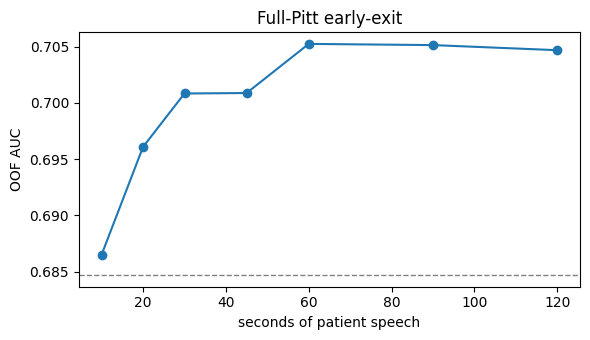

In [13]:
def utt_cutoff_len(fid,cut):
    meta=SEG.get(fid,[])
    if cut>=999: return max(1,min(len(meta),MAXU))
    return max(1,min(sum(1 for rs,_ in meta if rs<=cut),MAXU))
@torch.no_grad()
def predict_trunc(net,idxs,cut):
    net.eval(); P=[];T=[]
    for i in idxs:
        L,A,nf=pad_pair(FILES[i]); n=min(utt_cutoff_len(FILES[i],cut),nf)
        logit,_=net(torch.from_numpy(L)[None].to(DEVICE),torch.from_numpy(A)[None].to(DEVICE),torch.tensor([n]).to(DEVICE))
        P.append(torch.sigmoid(logit).item()); T.append(Y[i])
    return np.array(P),np.array(T)
# one repeat of CV: collect OOF predictions at each cutoff
sgkf=StratifiedGroupKFold(n_splits=CFG.KFOLDS,shuffle=True,random_state=0)
oof_cut={c:np.full(len(df),np.nan) for c in CFG.CUTOFFS_S}
for tr_idx,te_idx in sgkf.split(df,Y,groups=GROUPS):
    tr2,va=inner_val(tr_idx,0); sc=StandardScaler().fit(C_all[tr2]); C=sc.transform(C_all).astype("float32")
    net,_,_,_,_,_=train_once(tr2,va,te_idx,C,True,0)
    for cc in CFG.CUTOFFS_S:
        Pc,_=predict_trunc(net,te_idx,cc); oof_cut[cc][te_idx]=Pc
curve={c:roc_auc_score(Y,oof_cut[c]) for c in CFG.CUTOFFS_S}; full=curve[999]
print("OOF AUC vs seconds of patient speech:")
for c in CFG.CUTOFFS_S: print(f"  {('full' if c>=999 else str(c)+'s'):>5}: AUC {curve[c]:.3f}")
knee=next((c for c in CFG.CUTOFFS_S if curve[c]>=full-CFG.KNEE_TOL),999)
print(f"\n⏱️  Knee ≈ {knee}s")
try:
    xs=[c if c<999 else max(CFG.CUTOFFS_S[:-1])+30 for c in CFG.CUTOFFS_S]
    plt.figure(figsize=(6,3.5)); plt.plot(xs,[curve[c] for c in CFG.CUTOFFS_S],"o-")
    plt.axhline(full-CFG.KNEE_TOL,ls="--",c="gray",lw=1); plt.xlabel("seconds of patient speech"); plt.ylabel("OOF AUC"); plt.title("Full-Pitt early-exit"); plt.tight_layout(); plt.show()
except Exception as e: print("(plot skipped)",e)

## 12 · Summary

| Stage | Method |
|---|---|
| Data | full Pitt Cookie-Theft — 552 recordings, 292 speakers (309 AD / 243 CN) |
| Diarization | gold `.cha` PAR timestamps (swappable `diarize()` → Silero/pyannote for deployment) |
| Alignment | per utterance: [wav2vec2 + prosody] token + Whisper→BERT token |
| Fusion | gated cross-attention (text ⇄ audio) |
| Temporal | discourse encoder (BiGRU + attention) |
| Concepts | 24 clinical concepts (self-derived from audio), MSE-supervised bottleneck |
| Prediction | linear head → AD/CN + confidence + exact scorecard |
| **Evaluation** | **speaker-independent, repeated stratified GROUP k-fold; out-of-fold AUC/AUPRC/sens/spec/F1/MCC** |
| Explainability | all 23 concepts + fidelity + group differences + NL scorecards |
| Early-exit | OOF AUC vs seconds, real model truncated per utterance |

Reported out-of-fold over all 552 recordings (every recording predicted while held out), grouped by speaker — the rigorous estimate. AUC is the primary metric; deep-model F1 uses a validation-tuned threshold. Encoders frozen; only fusion+discourse+bottleneck train. Diarization is one swappable function, so the same model deploys as an audio-only screener.